In [1]:
%load_ext autoreload
%autoreload 2
import os
os.chdir('../..')
os.getcwd()

'/Users/antonismand/Documents/work/Darelab/Github/Query Builder/evaluation'

In [29]:
from querybuilder.discretization import KMeansBinning
from sqlcompletions.evaluator import run_n_tests, create_tests
from sqlcompletions.sqlparser import schema

specobj_attrs = [
    "specobj.z",
    "specobj.ra",
    "specobj.dec"
    ]

photoobj_attrs = [
    "photoobj.ra",
    "photoobj.g",
    "photoobj.dec",
    "photoobj.u",
    ]

Using sample from data/processed/bins/samples/specobj.csv.


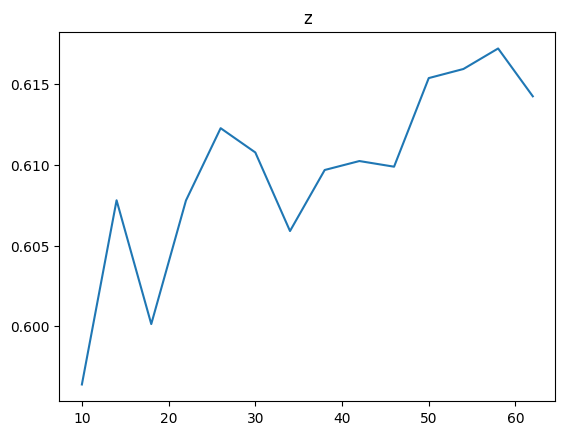

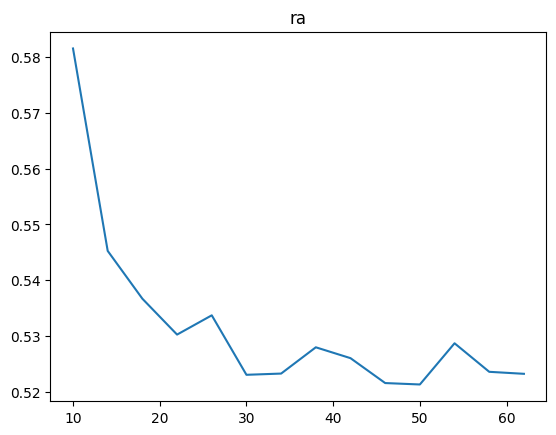

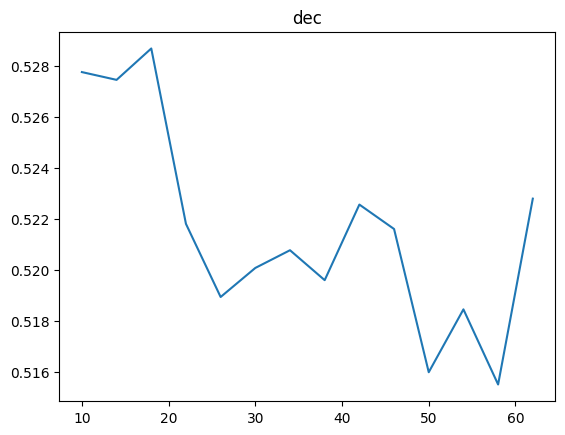

CPU times: user 8min 36s, sys: 1min 19s, total: 9min 55s
Wall time: 9min 17s


{'specobj.z': 58, 'specobj.ra': 10, 'specobj.dec': 18}

In [40]:
%%time
disc = KMeansBinning("cordis",specobj_attrs)
disc.analyze_bins(10, 64,4)

In [41]:
disc.create_bins()

Using sample from data/processed/bins/samples/photoobj.csv.


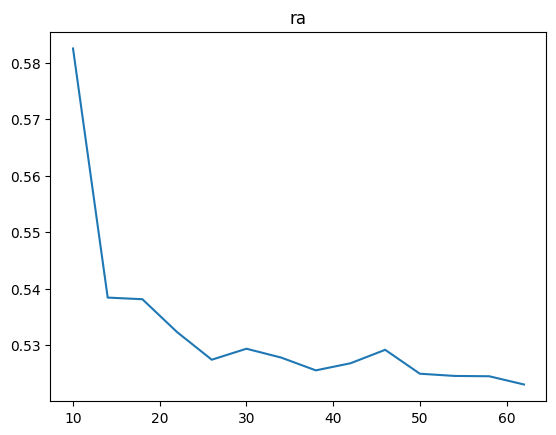

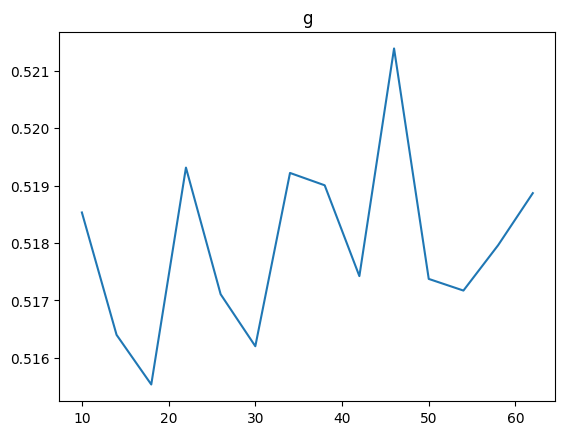

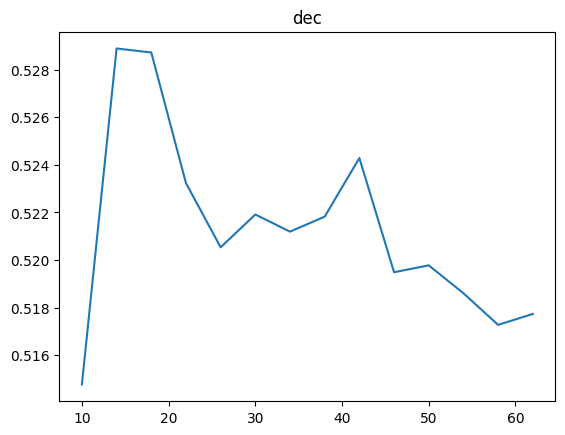

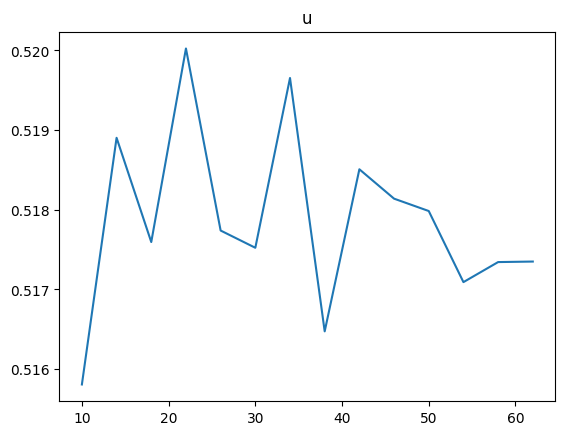

CPU times: user 10min, sys: 1min 43s, total: 11min 44s
Wall time: 10min 53s


{'photoobj.ra': 10, 'photoobj.g': 46, 'photoobj.dec': 14, 'photoobj.u': 22}

In [42]:
%%time
disc = KMeansBinning("cordis",photoobj_attrs)
disc.analyze_bins(10, 64,4)

In [43]:
disc.create_bins()

,Test,MAP@K,Execution Time
1,Best Bin,0.34,0.06
0,UCB,0.26,0.04
2,Most popular,0.23,0.17


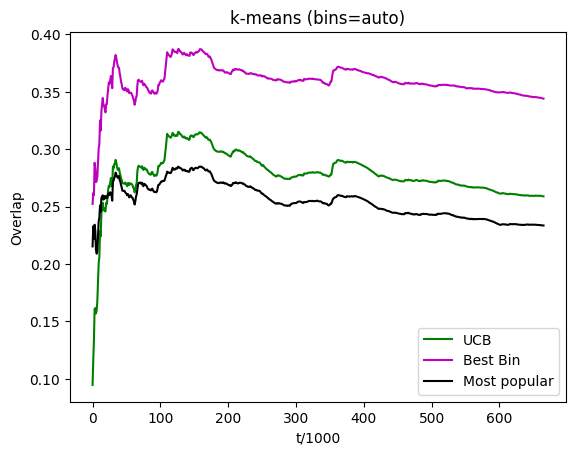

In [44]:
db = schema(db_stats=True,discretization_method="kmeans")
tests = create_tests(algorithms=["ucb","popularRegion","all"], clause=3, top_k = 5 , db = db , th = 500 )
run_n_tests(tests,"k-means (bins=auto)", ylabel = "Overlap").results

In [37]:
KMeansBinning("cordis",specobj_attrs).create_bins(20)
KMeansBinning("cordis",photoobj_attrs).create_bins(20)

Using sample from data/processed/bins/samples/specobj.csv.
Using sample from data/processed/bins/samples/photoobj.csv.


,Test,MAP@K,Execution Time
0,Best Bin,0.46,0.02
1,UCB,0.42,0.03
2,Most popular,0.41,0.06


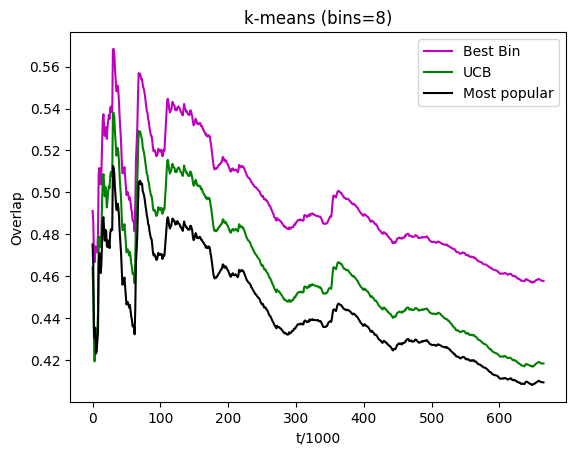

In [34]:
db = schema(db_stats=True,discretization_method="kmeans")
tests = create_tests(algorithms=["ucb","popularRegion","all"], clause=3, top_k = 5 , db = db , th = 500 )
run_n_tests(tests,"k-means (bins=8)", ylabel = "Overlap").results

,Test,MAP@K,Execution Time
0,Best Bin,0.45,0.02
1,UCB,0.40,0.03
2,Most popular,0.38,0.07


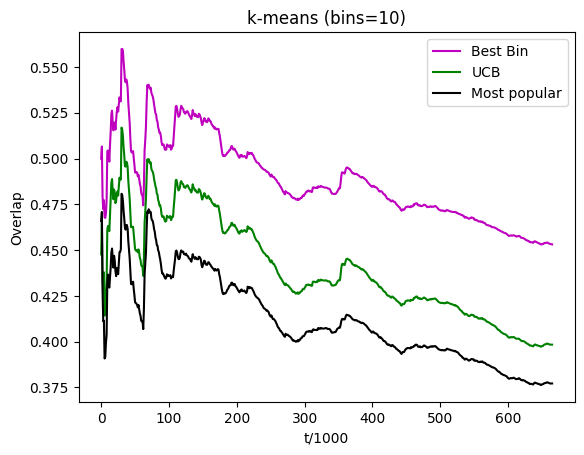

In [32]:
db = schema(db_stats=True,discretization_method="kmeans")
tests = create_tests(algorithms=["ucb","popularRegion","all"], clause=3, top_k = 5 , db = db , th = 500 )
run_n_tests(tests,"k-means (bins=10)", ylabel = "Overlap").results

,Test,MAP@K,Execution Time
0,Best Bin,0.45,0.02
1,UCB,0.37,0.03
2,Most popular,0.33,0.09


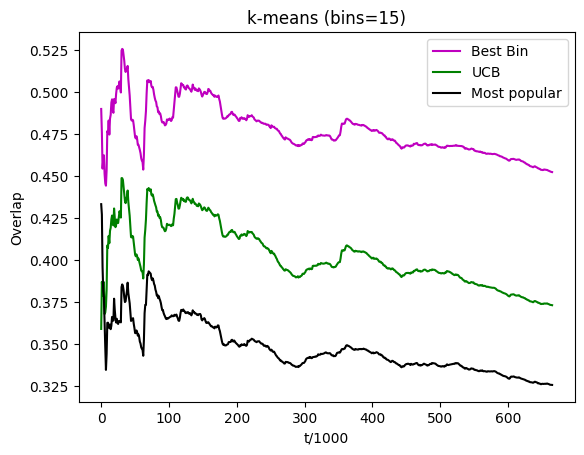

In [36]:
db = schema(db_stats=True,discretization_method="kmeans")
tests = create_tests(algorithms=["ucb","popularRegion","all"], clause=3, top_k = 5 , db = db , th = 500 )
run_n_tests(tests,"k-means (bins=15)", ylabel = "Overlap").results

,Test,MAP@K,Execution Time
1,Best Bin,0.43,0.03
0,UCB,0.34,0.03
2,Most popular,0.29,0.11


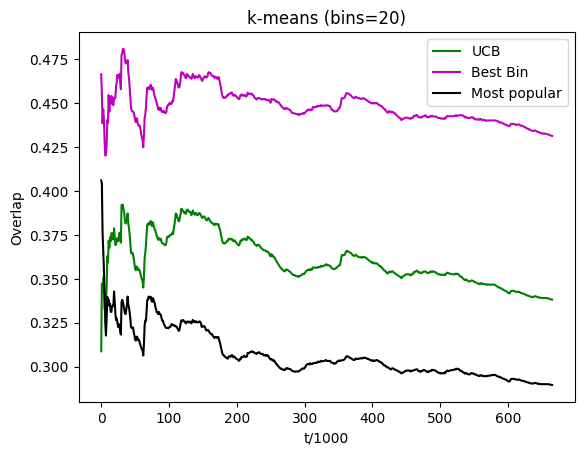

In [38]:
db = schema(db_stats=True,discretization_method="kmeans")
tests = create_tests(algorithms=["ucb","popularRegion","all"], clause=3, top_k = 5 , db = db , th = 500 )
run_n_tests(tests,"k-means (bins=20)", ylabel = "Overlap").results